In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\MI\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df['TotalCharges'].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [9]:
df['TotalCharges'].fillna(0, inplace=True)

C:\Users\MI\AppData\Local\Temp\ipykernel_5416\171940771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [10]:
df.drop('customerID', axis=1, inplace=True)

In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [13]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Separating categorical and numerical data

In [14]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

## Encoding Categorical Variables

In [15]:
df_encoded = pd.get_dummies(df,  columns=cat_cols, drop_first=True)

In [16]:
df_encoded.isnull().sum().sum()

np.int64(0)

In [17]:
df_encoded.shape

(7043, 31)

In [18]:
df_encoded.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [19]:
df_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

## Feature Engineering

In [20]:
# Tenure and Loyalty Features

df_encoded['tenure_group'] = pd.cut(
    df_encoded['tenure'],
    bins=[0, 6, 12, 24, 60, 100],
    labels=['0-6', '6-12', '12-24', '24-60', '60+']
)

In [21]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,0-6
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,True,False,False,False,False,True,24-60
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,True,False,False,True,0-6
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,24-60
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,0-6


In [22]:
# Revenue and value Features

df_encoded['high_value_customer'] = (df_encoded['TotalCharges'] > df_encoded['TotalCharges'].median()).astype(int)

df_encoded['average_monthly_spend'] = (df_encoded['TotalCharges'] / df_encoded['tenure'] + 1)

In [23]:
df_encoded.head(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,high_value_customer,average_monthly_spend
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,True,False,True,False,0-6,0,30.850000
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,True,False,False,False,False,True,24-60,1,56.573529


In [24]:
# Services Engagement Features

service_cols = [
    "PhoneService_Yes",
    "MultipleLines_Yes",
    "OnlineSecurity_Yes",
    "OnlineBackup_Yes",
    "DeviceProtection_Yes",
    "TechSupport_Yes",
    "StreamingTV_Yes",
    "StreamingMovies_Yes"
]

df_encoded['num_services'] = df_encoded[service_cols].sum(axis=1)

df_encoded['low_engagement'] = (df_encoded['num_services'] <= 2).astype(int)

In [25]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,high_value_customer,average_monthly_spend,num_services,low_engagement
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,True,False,True,False,0-6,0,30.850000,1,1
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,24-60,1,56.573529,3,0
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,True,False,False,True,0-6,0,55.075000,3,0
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,False,24-60,1,41.905556,3,0
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,True,False,True,False,0-6,0,76.825000,1,1


In [26]:
# Risk Indicator Features

df_encoded['high_monthly_charge'] = (df_encoded['MonthlyCharges'] > df_encoded['MonthlyCharges'].quantile(0.75)).astype(int)

df_encoded['short_tenure_high_charge'] = ( (df_encoded['tenure'] < 6) & (df_encoded['MonthlyCharges'] > df_encoded['MonthlyCharges'].median()) ).astype(int)

In [27]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,high_value_customer,average_monthly_spend,num_services,low_engagement,high_monthly_charge,short_tenure_high_charge
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,True,False,0-6,0,30.850000,1,1,0,0
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,True,24-60,1,56.573529,3,0,0,0
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,True,0-6,0,55.075000,3,0,0,0
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,24-60,1,41.905556,3,0,0,0
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,True,False,0-6,0,76.825000,1,1,0,1


In [28]:
# Contract Stability Features

df_encoded['long_term_contract'] = ( (df_encoded.get('Contract_One year', 0) == 1) | (df_encoded.get('Contract_Two year', 0) == 1) ).astype(int)

In [29]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,high_value_customer,average_monthly_spend,num_services,low_engagement,high_monthly_charge,short_tenure_high_charge,long_term_contract
0,0,1,29.85,29.85,0,False,True,False,False,True,...,True,False,0-6,0,30.850000,1,1,0,0,0
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,True,24-60,1,56.573529,3,0,0,0,1
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,True,0-6,0,55.075000,3,0,0,0,0
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,24-60,1,41.905556,3,0,0,0,1
4,0,2,70.70,151.65,1,False,False,False,True,False,...,True,False,0-6,0,76.825000,1,1,0,1,0


## EDA

In [30]:
# Overall Churn Rate

churn_rate = df_encoded["Churn"].mean()
print(f"Churn Rate: {churn_rate:.2%}")  

Churn Rate: 26.54%


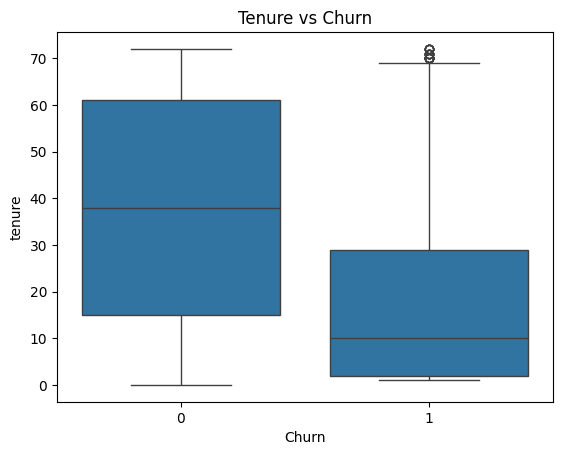

In [31]:
# Tenure vs Churn - tells if new customers churn more?

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Churn", y="tenure", data=df_encoded)
plt.title("Tenure vs Churn")
plt.show()

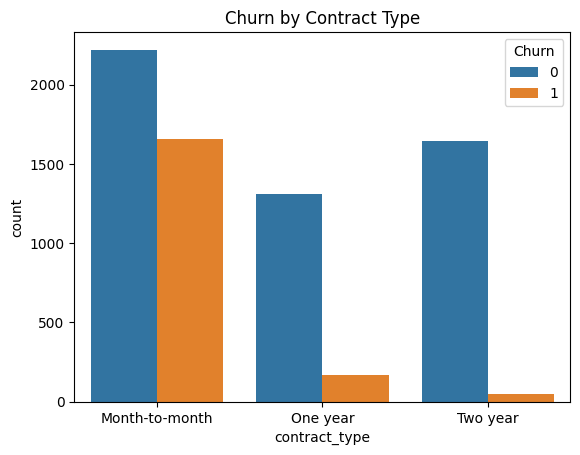

In [32]:
# Does contract type effect churn?

df_encoded["contract_type"] = "Month-to-month"
df_encoded.loc[df_encoded["Contract_One year"] == 1, "contract_type"] = "One year"
df_encoded.loc[df_encoded["Contract_Two year"] == 1, "contract_type"] = "Two year"

sns.countplot(x="contract_type", hue="Churn", data=df_encoded)
plt.title("Churn by Contract Type")
plt.show()


Text(0.5, 1.0, 'Monthly Charges vs Churn')

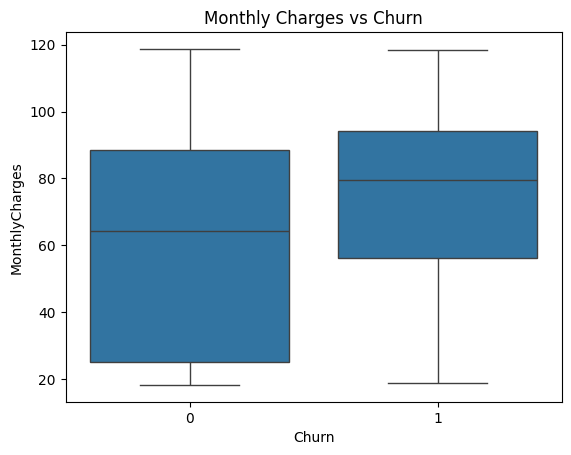

In [33]:
# Does price increase churn?

sns.boxplot(x='Churn', y='MonthlyCharges', data=df_encoded)
plt.title("Monthly Charges vs Churn")

Text(0.5, 1.0, 'Customer Value vs Churn')

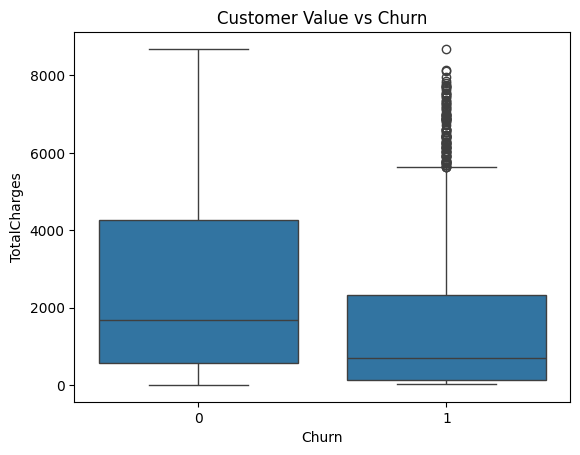

In [34]:
# Are high value customers churning?

sns.boxplot(x='Churn', y='TotalCharges', data=df_encoded)
plt.title('Customer Value vs Churn')

Text(0.5, 1.0, 'Service Engagement vs Churn')

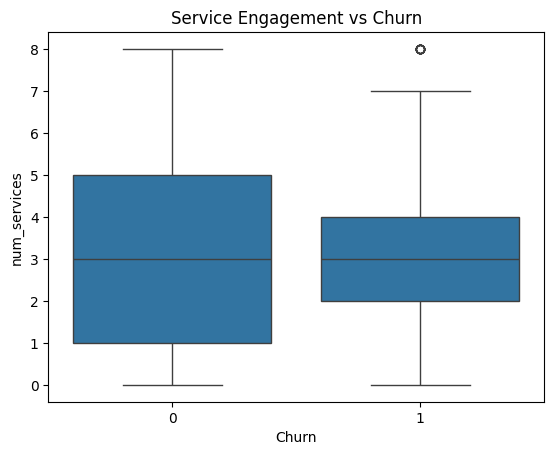

In [35]:
# Service Engagement vs Churn

sns.boxplot(x='Churn', y='num_services', data=df_encoded)
plt.title('Service Engagement vs Churn')

Text(0.5, 1.0, 'High-Risk Customer Segment')

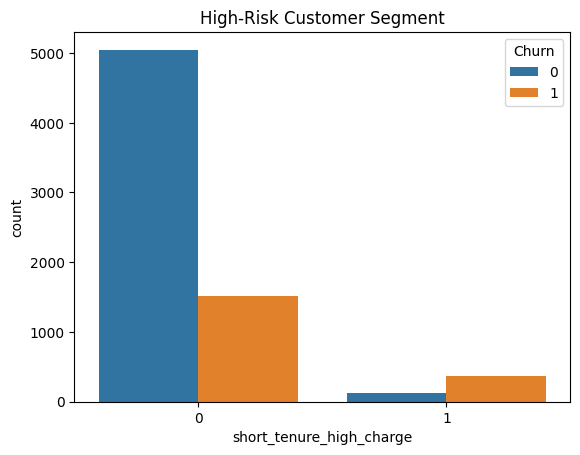

In [36]:
sns.countplot(x='short_tenure_high_charge', hue='Churn', data=df_encoded)
plt.title('High-Risk Customer Segment')

In [37]:
corr = df_encoded.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

print(corr.head(10))
print(corr.tail(10))


Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
short_tenure_high_charge          0.293115
MonthlyCharges                    0.193356
average_monthly_spend             0.192033
PaperlessBilling_Yes              0.191825
SeniorCitizen                     0.150889
high_monthly_charge               0.082833
StreamingTV_Yes                   0.063228
Name: Churn, dtype: float64
StreamingTV_No internet service        -0.227890
OnlineSecurity_No internet service     -0.227890
InternetService_No                     -0.227890
TechSupport_No internet service        -0.227890
OnlineBackup_No internet service       -0.227890
DeviceProtection_No internet service   -0.227890
StreamingMovies_No internet service    -0.227890
Contract_Two year                      -0.302253
tenure                                 -0.352229
long_term_contract                     -0.405103
Name: Churn, dtype: float64


## Building Churn Prediction Model

In [38]:
# Definig Features

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [39]:
# Train-test-split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
X_train.dtypes

SeniorCitizen                               int64
tenure                                      int64
MonthlyCharges                            float64
TotalCharges                              float64
gender_Male                                  bool
Partner_Yes                                  bool
Dependents_Yes                               bool
PhoneService_Yes                             bool
MultipleLines_No phone service               bool
MultipleLines_Yes                            bool
InternetService_Fiber optic                  bool
InternetService_No                           bool
OnlineSecurity_No internet service           bool
OnlineSecurity_Yes                           bool
OnlineBackup_No internet service             bool
OnlineBackup_Yes                             bool
DeviceProtection_No internet service         bool
DeviceProtection_Yes                         bool
TechSupport_No internet service              bool
TechSupport_Yes                              bool


In [41]:
X_train_num = X_train.select_dtypes(include=["int64", "float64"])
X_test_num  = X_test.select_dtypes(include=["int64", "float64"])

In [42]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train_num)
X_test_imputed = imputer.transform(X_test_num)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled  = scaler.transform(X_test_imputed)

In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [45]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[744, 291],
       [ 80, 294]])

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [48]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
roc_auc

np.float64(0.8335916711875792)

In [49]:
import pandas as pd


In [50]:
numeric_features = X_train_num.columns

feature_importance = pd.Series(
    model.coef_[0],
    index=numeric_features
).sort_values()

print(feature_importance.tail(10))   # increases churn
print(feature_importance.head(10))   # reduces churn


num_services               -0.615644
long_term_contract         -0.589981
high_value_customer        -0.068269
low_engagement             -0.019192
average_monthly_spend       0.002757
short_tenure_high_charge    0.105593
SeniorCitizen               0.138299
high_monthly_charge         0.148840
TotalCharges                0.323873
MonthlyCharges              1.029187
dtype: float64
tenure                     -0.901344
num_services               -0.615644
long_term_contract         -0.589981
high_value_customer        -0.068269
low_engagement             -0.019192
average_monthly_spend       0.002757
short_tenure_high_charge    0.105593
SeniorCitizen               0.138299
high_monthly_charge         0.148840
TotalCharges                0.323873
dtype: float64


## Revenue at Risk Calculation

In [51]:
risk_df = X_test.copy()
risk_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,PaymentMethod_Mailed check,tenure_group,high_value_customer,average_monthly_spend,num_services,low_engagement,high_monthly_charge,short_tenure_high_charge,long_term_contract,contract_type
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,False,60+,1,118.613889,8,0,1,0,1,Two year
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,False,6-12,0,114.568750,5,0,1,0,0,Month-to-month
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,False,24-60,1,79.321951,6,0,0,0,1,One year
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,False,12-24,1,82.597222,3,0,0,0,0,Month-to-month
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,False,60+,1,83.213194,7,0,0,0,1,Two year


In [52]:
risk_df["actual_churn"] = y_test.values
risk_df.head(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,tenure_group,high_value_customer,average_monthly_spend,num_services,low_engagement,high_monthly_charge,short_tenure_high_charge,long_term_contract,contract_type,actual_churn
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,60+,1,118.613889,8,0,1,0,1,Two year,0
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,6-12,0,114.568750,5,0,1,0,0,Month-to-month,0
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,24-60,1,79.321951,6,0,0,0,1,One year,0
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,12-24,1,82.597222,3,0,0,0,0,Month-to-month,0
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,60+,1,83.213194,7,0,0,0,1,Two year,0


In [53]:
risk_df["churn_probability"] = y_prob
risk_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,high_value_customer,average_monthly_spend,num_services,low_engagement,high_monthly_charge,short_tenure_high_charge,long_term_contract,contract_type,actual_churn,churn_probability
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,1,118.613889,8,0,1,0,1,Two year,0,0.209480
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,0,114.568750,5,0,1,0,0,Month-to-month,0,0.886879
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,1,79.321951,6,0,0,0,1,One year,0,0.129113
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,1,82.597222,3,0,0,0,0,Month-to-month,0,0.681455
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,1,83.213194,7,0,0,0,1,Two year,0,0.056710


In [54]:
risk_df["customer_value"] = X_test["TotalCharges"].values
risk_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,average_monthly_spend,num_services,low_engagement,high_monthly_charge,short_tenure_high_charge,long_term_contract,contract_type,actual_churn,churn_probability,customer_value
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,118.613889,8,0,1,0,1,Two year,0,0.209480,8468.20
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,114.568750,5,0,1,0,0,Month-to-month,0,0.886879,908.55
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,79.321951,6,0,0,0,1,One year,0,0.129113,3211.20
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,82.597222,3,0,0,0,0,Month-to-month,0,0.681455,1468.75
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,83.213194,7,0,0,0,1,Two year,0,0.056710,5919.35


In [55]:
risk_df["revenue_at_risk"] = (
    risk_df["churn_probability"] * risk_df["customer_value"]
)

In [56]:
risk_df.head(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,num_services,low_engagement,high_monthly_charge,short_tenure_high_charge,long_term_contract,contract_type,actual_churn,churn_probability,customer_value,revenue_at_risk
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,8,0,1,0,1,Two year,0,0.209480,8468.20,1773.915138
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,5,0,1,0,0,Month-to-month,0,0.886879,908.55,805.774106
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,6,0,0,0,1,One year,0,0.129113,3211.20,414.606324
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,3,0,0,0,0,Month-to-month,0,0.681455,1468.75,1000.886951
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,7,0,0,0,1,Two year,0,0.056710,5919.35,335.687146


In [57]:
risk_df_sorted = risk_df.sort_values(
    by="revenue_at_risk",
    ascending=False
)

risk_df_sorted.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,num_services,low_engagement,high_monthly_charge,short_tenure_high_charge,long_term_contract,contract_type,actual_churn,churn_probability,customer_value,revenue_at_risk
2860,1,67,101.40,6841.05,True,False,False,True,False,True,...,5,0,1,0,0,Month-to-month,0,0.655371,6841.05,4483.426539
2282,1,66,99.50,6822.15,True,True,True,True,False,True,...,5,0,1,0,0,Month-to-month,1,0.648389,6822.15,4423.404363
3856,0,61,114.10,7132.15,True,True,False,True,False,True,...,7,0,1,0,0,Month-to-month,0,0.591609,7132.15,4219.445550
7023,1,63,103.50,6479.40,False,True,False,True,False,True,...,6,0,1,0,0,Month-to-month,0,0.625418,6479.40,4052.333966
3411,1,53,101.90,5549.40,True,True,False,True,False,True,...,5,0,1,0,0,Month-to-month,1,0.729117,5549.40,4046.161198
2850,1,60,99.00,6017.90,True,True,False,True,False,True,...,5,0,1,0,0,Month-to-month,0,0.668288,6017.90,4021.692157
2079,0,70,106.05,7554.05,True,True,True,True,False,True,...,6,0,1,0,0,Month-to-month,0,0.530437,7554.05,4006.948183
3472,1,56,104.75,5841.35,False,False,False,True,False,True,...,6,0,1,0,0,Month-to-month,0,0.672957,5841.35,3930.975323
3922,1,67,94.65,6079.00,True,True,False,True,False,True,...,4,0,1,0,0,Month-to-month,0,0.645690,6079.00,3925.150398
2576,0,53,108.25,5935.10,False,True,True,True,False,False,...,6,0,1,0,0,Month-to-month,0,0.643609,5935.10,3819.881188


In [58]:
total_revenue_risk = risk_df["revenue_at_risk"].sum()
total_revenue_risk

np.float64(1010656.4862355483)

In [59]:
median_customer_value = risk_df['customer_value'].median()

def risk_segment(row):
    if row['churn_probability'] > 0.7 and row['customer_value'] > median_customer_value:
        return 'High Risk - High Value'
    elif row['churn_probability'] > 0.5:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_df['risk_segment'] = risk_df.apply(risk_segment, axis=1)

In [60]:
risk_df['risk_segment'].value_counts()

risk_segment
Low Risk                  824
Medium Risk               486
High Risk - High Value     99
Name: count, dtype: int64

In [61]:
# Revenue at Risk per segment

segment_risk = (
    risk_df
    .groupby('risk_segment')
    .agg(
        customers=('revenue_at_risk', 'count'),
        total_revenue_at_risk=('revenue_at_risk', 'sum')
    )
    .sort_values('total_revenue_at_risk', ascending=False)
)

segment_risk

,customers,total_revenue_at_risk
risk_segment,,
Low Risk,824,459471.018076
Medium Risk,486,367450.559104
High Risk - High Value,99,183734.909055


## Retention Strategy Engine

In [62]:
def retention_strategy(row):

    if row['risk_segment'] == 'High Risk - High Value':
        return 'Personal Call + Special retention offer'
    elif row['short_tenure_high_charge'] == 1:
        return 'Onboarding Discount for 3 months'
    elif row['high_monthly_charge'] == 1:
        return 'Offer plan downgrade or loyalty discount'
    elif row['PaymentMethod_Electronic check'] == 1:
        return 'Incentivize auto-pay setup'
    elif row['risk_segment'] == 'Medium Risk':
        return 'Engagement Mail + Limited Time offer'
    else:
        return 'No action required'
    
risk_df['retention_action'] = risk_df.apply(retention_strategy, axis=1)

In [63]:
risk_df[
    ["churn_probability", "customer_value", "revenue_at_risk",
     "risk_segment", "retention_action"]
].head(10)

,churn_probability,customer_value,revenue_at_risk,risk_segment,retention_action
437,0.209480,8468.20,1773.915138,Low Risk,Offer plan downgrade or loyalty discount
2280,0.886879,908.55,805.774106,Medium Risk,Offer plan downgrade or loyalty discount
2235,0.129113,3211.20,414.606324,Low Risk,No action required
4460,0.681455,1468.75,1000.886951,Medium Risk,Incentivize auto-pay setup
3761,0.056710,5919.35,335.687146,Low Risk,No action required
5748,0.770951,1992.55,1536.159327,High Risk - High Value,Personal Call + Special retention offer
3568,0.765754,1956.40,1498.121611,High Risk - High Value,Personal Call + Special retention offer
2976,0.293050,439.20,128.707499,Low Risk,No action required
5928,0.034387,1311.60,45.101571,Low Risk,No action required
1639,0.652217,770.60,502.598661,Medium Risk,Incentivize auto-pay setup


In [64]:
risk_df["retention_action"].value_counts()

retention_action
No action required                          564
Offer plan downgrade or loyalty discount    250
Incentivize auto-pay setup                  233
Engagement Mail + Limited Time offer        160
Onboarding Discount for 3 months            103
Personal Call + Special retention offer      99
Name: count, dtype: int64

In [65]:
risk_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,high_monthly_charge,short_tenure_high_charge,long_term_contract,contract_type,actual_churn,churn_probability,customer_value,revenue_at_risk,risk_segment,retention_action
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,1,0,1,Two year,0,0.209480,8468.20,1773.915138,Low Risk,Offer plan downgrade or loyalty discount
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,1,0,0,Month-to-month,0,0.886879,908.55,805.774106,Medium Risk,Offer plan downgrade or loyalty discount
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,0,0,1,One year,0,0.129113,3211.20,414.606324,Low Risk,No action required
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,0,0,0,Month-to-month,0,0.681455,1468.75,1000.886951,Medium Risk,Incentivize auto-pay setup
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,0,0,1,Two year,0,0.056710,5919.35,335.687146,Low Risk,No action required


In [66]:
risk_df.shape

(1409, 45)

In [67]:
dashboard_df = risk_df.copy()

dashboard_df["Churn"] = dashboard_df["actual_churn"]
dashboard_df["Tenure"] = X_test["tenure"]
dashboard_df["MonthlyCharges"] = X_test["MonthlyCharges"]
dashboard_df["Contract_One year"] = X_test["Contract_One year"]
dashboard_df["Contract_Two year"] = X_test["Contract_Two year"]


In [ ]:
dashboard_df.to_csv("risk_analysis_dashboard.csv", index=False)